# Multilingual Language Identification

An NLP system for identifying the language of a text sample across 20 languages.

The notebook compares Bag of Words, word-level TF-IDF, and character-level TF-IDF with
Naive Bayes, Logistic Regression, and Linear SVM. The strongest experiment achieved
approximately **99.39% accuracy** using **Linear SVM with character-level TF-IDF**.

> The ALLAM experiment at the end is optional and requires a compatible GPU and a
> Hugging Face token stored securely in Google Colab Secrets.


## 1. Setup and Imports


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC


## 2. Dataset

Download the **Language Identification Dataset (20 Languages)** from Kaggle and place
`train.csv` in the same directory as this notebook.


In [ ]:
DATA_PATH = Path("train.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "train.csv was not found. Download the dataset from Kaggle and place "
        "train.csv beside this notebook."
    )

df = pd.read_csv(DATA_PATH)


### Initial Data Inspection


In [3]:
df.shape

(70000, 2)

In [4]:
df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  70000 non-null  object
 1   text    70000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

,0
labels,0
text,0


In [7]:
df.duplicated().sum()

np.int64(1020)

In [8]:
df = df.drop_duplicates()

In [9]:
df['labels'].value_counts()

,count
labels,
ja,3500
de,3499
en,3499
es,3498
fr,3495
zh,3491
bg,3464
tr,3464
vi,3464


## 3. Train-Test Split and Text Cleaning

The dataset is split using stratification so that language proportions remain consistent
between the training and test sets.


In [10]:
X = df['text']
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)


In [11]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

## 4. Additional Preprocessing Experiments

Stop-word removal, stemming, and lemmatization are included as comparison experiments.
Because these tools are primarily English-oriented, their use across all 20 languages should
be interpreted as an experimental baseline rather than language-specific preprocessing.


In [ ]:
english_stopwords = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(str(text))
    filtered_words = [
        word for word in tokens
        if word.lower() not in english_stopwords
    ]
    return " ".join(filtered_words)

X_train_no_stopwords = X_train_clean.apply(remove_stopwords)
X_test_no_stopwords = X_test_clean.apply(remove_stopwords)


In [13]:
sample_text = X_train_clean.iloc[0]

tokens = word_tokenize(sample_text)

print("Original text:")
print(sample_text)

print("\nTokens:")
print(tokens)

Original text:
ใช่ มัน มี มัน มี การ จับ ใคร สัก คน บน นั้น แต่ ไม่มี การ ระบุ รอย หรือ อะไร เลย

Tokens:
['ใช่', 'มัน', 'มี', 'มัน', 'มี', 'การ', 'จับ', 'ใคร', 'สัก', 'คน', 'บน', 'นั้น', 'แต่', 'ไม่มี', 'การ', 'ระบุ', 'รอย', 'หรือ', 'อะไร', 'เลย']


In [14]:
stemmer = PorterStemmer()

def apply_stemming(text):
    tokens = word_tokenize(str(text))
    stemmed_words = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_words)

X_train_stemmed = X_train_clean.apply(apply_stemming)
X_test_stemmed = X_test_clean.apply(apply_stemming)

print(X_train_stemmed.head())

5293     ใช่ มัน มี มัน มี การ จับ ใคร สัก คน บน นั้น แ...
45261    foi levado para um hospit para radiografia de ...
18995    une cours poursuit avec quelqu bon moment de r...
8591     เรา ไม่ สามารถ ทำ มัน ได้ สำหรับ $ , บอ กว่า a...
34321    اور اس کے تمام طوائف ، طوائف ، طوائف اور قابو ...
Name: text, dtype: object


In [15]:
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(text):
    tokens = word_tokenize(str(text))
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_words)

X_train_lemmatized = X_train_clean.apply(apply_lemmatization)
X_test_lemmatized = X_test_clean.apply(apply_lemmatization)

print(X_train_lemmatized.head())

5293     ใช่ มัน มี มัน มี การ จับ ใคร สัก คน บน นั้น แ...
45261    foi levado para um hospital para radiografias ...
18995    une course poursuite avec quelques bon moment ...
8591     เรา ไม่ สามารถ ทำ มัน ได้ สำหรับ $ , บอ กว่า a...
34321    اور اس کے تمام طوائف ، طوائف ، طوائف اور قابو ...
Name: text, dtype: object


## 5. Feature Extraction

Three text representations are compared:

- Bag of Words
- Word-level TF-IDF
- Character-level TF-IDF using character n-grams from 2 to 5


In [16]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train_clean)
X_test_bow = bow_vectorizer.transform(X_test_clean)

In [17]:
tfidf_word = TfidfVectorizer(max_features=5000)

X_train_tfidf_word = tfidf_word.fit_transform(X_train_clean)
X_test_tfidf_word = tfidf_word.transform(X_test_clean)


In [18]:
tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=5000
)

X_train_tfidf_char = tfidf_char.fit_transform(X_train_clean)
X_test_tfidf_char = tfidf_char.transform(X_test_clean)


In [19]:
tfidf_stem = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=5000
)

X_train_tfidf_stem = tfidf_stem.fit_transform(X_train_stemmed)
X_test_tfidf_stem = tfidf_stem.transform(X_test_stemmed)


In [20]:
tfidf_lemma = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=5000
)

X_train_tfidf_lemma = tfidf_lemma.fit_transform(X_train_lemmatized)
X_test_tfidf_lemma = tfidf_lemma.transform(X_test_lemmatized)


In [21]:
tfidf_stopwords = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=5000
)

X_train_tfidf_stopwords = tfidf_stopwords.fit_transform(X_train_no_stopwords)
X_test_tfidf_stopwords = tfidf_stopwords.transform(X_test_no_stopwords)


## 6. Model Training and Evaluation


In [22]:
nb = MultinomialNB()

nb.fit(X_train_bow, y_train)

nb_predictions = nb.predict(X_test_bow)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes with BoW Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_predictions))

Naive Bayes with BoW Accuracy: 0.9179472310814729
              precision    recall  f1-score   support

          ar       0.99      0.97      0.98       693
          bg       0.96      0.97      0.96       693
          de       0.99      1.00      1.00       700
          el       1.00      0.99      1.00       693
          en       0.94      1.00      0.97       700
          es       0.96      1.00      0.98       699
          fr       0.99      1.00      1.00       699
          hi       1.00      0.98      0.99       693
          it       0.99      0.98      0.98       669
          ja       0.43      0.99      0.60       700
          nl       0.98      0.95      0.97       668
          pl       0.98      0.78      0.87       667
          pt       0.98      0.96      0.97       670
          ru       0.99      0.91      0.95       692
          sw       0.93      0.95      0.94       693
          th       1.00      0.99      1.00       692
          tr       0.99      0.

In [23]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf_char, y_train)

nb_tfidf_predictions = nb_tfidf.predict(X_test_tfidf_char)

nb_tfidf_accuracy = accuracy_score(y_test, nb_tfidf_predictions)

print("Naive Bayes + Character TF-IDF Accuracy:", nb_tfidf_accuracy)
print(classification_report(y_test, nb_tfidf_predictions))

Naive Bayes + Character TF-IDF Accuracy: 0.9658596694694114
              precision    recall  f1-score   support

          ar       0.99      1.00      1.00       693
          bg       0.98      0.97      0.98       693
          de       1.00      1.00      1.00       700
          el       1.00      1.00      1.00       693
          en       0.94      1.00      0.97       700
          es       0.99      1.00      0.99       699
          fr       0.99      1.00      1.00       699
          hi       1.00      1.00      1.00       693
          it       0.99      0.99      0.99       669
          ja       0.68      1.00      0.81       700
          nl       0.99      0.99      0.99       668
          pl       0.99      0.99      0.99       667
          pt       0.99      0.99      0.99       670
          ru       0.98      0.98      0.98       692
          sw       0.99      0.94      0.96       693
          th       1.00      1.00      1.00       692
          tr       0.

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf_char, y_train)

lr_predictions = lr.predict(X_test_tfidf_char)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression with Character TF-IDF Accuracy:", lr_accuracy)
print(classification_report(y_test, lr_predictions))

Logistic Regression with Character TF-IDF Accuracy: 0.9920266743983763
              precision    recall  f1-score   support

          ar       1.00      0.99      1.00       693
          bg       0.99      0.98      0.98       693
          de       1.00      1.00      1.00       700
          el       1.00      1.00      1.00       693
          en       0.98      1.00      0.99       700
          es       1.00      0.99      1.00       699
          fr       1.00      1.00      1.00       699
          hi       1.00      0.99      1.00       693
          it       0.99      0.99      0.99       669
          ja       1.00      0.99      1.00       700
          nl       0.99      0.99      0.99       668
          pl       0.99      0.99      0.99       667
          pt       0.99      1.00      0.99       670
          ru       0.98      0.98      0.98       692
          sw       0.99      0.97      0.98       693
          th       1.00      1.00      1.00       692
          

In [25]:
svm = LinearSVC(max_iter=2000)

svm.fit(X_train_tfidf_char, y_train)

svm_predictions = svm.predict(X_test_tfidf_char)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM with Character TF-IDF Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_predictions))

SVM with Character TF-IDF Accuracy: 0.993983763409684
              precision    recall  f1-score   support

          ar       1.00      0.99      0.99       693
          bg       0.99      0.99      0.99       693
          de       1.00      1.00      1.00       700
          el       1.00      1.00      1.00       693
          en       0.99      1.00      1.00       700
          es       1.00      1.00      1.00       699
          fr       1.00      1.00      1.00       699
          hi       1.00      1.00      1.00       693
          it       0.99      0.99      0.99       669
          ja       1.00      0.99      1.00       700
          nl       0.99      0.99      0.99       668
          pl       0.99      1.00      0.99       667
          pt       0.99      1.00      0.99       670
          ru       0.99      0.99      0.99       692
          sw       0.99      0.98      0.99       693
          th       1.00      1.00      1.00       692
          tr       0.99    

In [26]:
svm_word = LinearSVC(max_iter=2000)

svm_word.fit(X_train_tfidf_word, y_train)

svm_word_predictions = svm_word.predict(X_test_tfidf_word)

svm_word_accuracy = accuracy_score(y_test, svm_word_predictions)

print("SVM with Word-Level TF-IDF Accuracy:", svm_word_accuracy)
print(classification_report(y_test, svm_word_predictions))

SVM with Word-Level TF-IDF Accuracy: 0.9241809220063787
              precision    recall  f1-score   support

          ar       1.00      0.96      0.98       693
          bg       0.97      0.96      0.97       693
          de       1.00      1.00      1.00       700
          el       1.00      0.99      0.99       693
          en       0.99      1.00      0.99       700
          es       0.99      1.00      0.99       699
          fr       1.00      0.99      0.99       699
          hi       1.00      0.98      0.99       693
          it       0.98      0.97      0.98       669
          ja       0.87      0.09      0.16       700
          nl       0.98      0.96      0.97       668
          pl       0.95      0.86      0.90       667
          pt       0.98      0.98      0.98       670
          ru       0.98      0.92      0.95       692
          sw       0.99      0.95      0.97       693
          th       1.00      0.99      0.99       692
          tr       0.98  

In [27]:
svm_bow = LinearSVC(max_iter=2000)

svm_bow.fit(X_train_bow, y_train)

svm_bow_predictions = svm_bow.predict(X_test_bow)

svm_bow_accuracy = accuracy_score(y_test, svm_bow_predictions)

print("SVM with BoW Accuracy:", svm_bow_accuracy)
print(classification_report(y_test, svm_bow_predictions))

SVM with BoW Accuracy: 0.9197593505363874
              precision    recall  f1-score   support

          ar       1.00      0.96      0.98       693
          bg       0.97      0.96      0.96       693
          de       1.00      0.99      1.00       700
          el       1.00      0.98      0.99       693
          en       0.99      0.99      0.99       700
          es       0.99      0.99      0.99       699
          fr       1.00      0.99      0.99       699
          hi       1.00      0.97      0.98       693
          it       0.98      0.97      0.98       669
          ja       0.85      0.09      0.16       700
          nl       0.98      0.95      0.96       668
          pl       0.95      0.86      0.90       667
          pt       0.98      0.97      0.98       670
          ru       0.98      0.92      0.95       692
          sw       0.98      0.94      0.96       693
          th       1.00      0.98      0.99       692
          tr       0.98      0.93      

In [28]:
svm_stem = LinearSVC(max_iter=2000)

svm_stem.fit(X_train_tfidf_stem, y_train)

svm_stem_predictions = svm_stem.predict(X_test_tfidf_stem)

svm_stem_accuracy = accuracy_score(y_test, svm_stem_predictions)

print("SVM with Character TF-IDF and Stemming Accuracy:", svm_stem_accuracy)
print(classification_report(y_test, svm_stem_predictions))

SVM with Character TF-IDF and Stemming Accuracy: 0.9934763699623079
              precision    recall  f1-score   support

          ar       1.00      0.99      0.99       693
          bg       0.99      0.98      0.98       693
          de       1.00      1.00      1.00       700
          el       1.00      1.00      1.00       693
          en       0.99      1.00      0.99       700
          es       1.00      1.00      1.00       699
          fr       1.00      1.00      1.00       699
          hi       1.00      1.00      1.00       693
          it       0.99      1.00      0.99       669
          ja       1.00      0.99      1.00       700
          nl       0.99      0.99      0.99       668
          pl       0.99      1.00      0.99       667
          pt       0.99      1.00      0.99       670
          ru       0.98      0.99      0.98       692
          sw       0.99      0.97      0.98       693
          th       1.00      1.00      1.00       692
          tr 

In [29]:
svm_lemma = LinearSVC(max_iter=2000)

svm_lemma.fit(X_train_tfidf_lemma, y_train)

svm_lemma_predictions = svm_lemma.predict(X_test_tfidf_lemma)

svm_lemma_accuracy = accuracy_score(y_test, svm_lemma_predictions)

print("SVM with Character TF-IDF and Lemmatization Accuracy:", svm_lemma_accuracy)
print(classification_report(y_test, svm_lemma_predictions))

SVM with Character TF-IDF and Lemmatization Accuracy: 0.9937663090750942
              precision    recall  f1-score   support

          ar       1.00      0.99      0.99       693
          bg       0.99      0.99      0.99       693
          de       1.00      1.00      1.00       700
          el       1.00      1.00      1.00       693
          en       0.99      1.00      0.99       700
          es       1.00      1.00      1.00       699
          fr       1.00      1.00      1.00       699
          hi       1.00      1.00      1.00       693
          it       0.99      1.00      0.99       669
          ja       1.00      0.99      1.00       700
          nl       0.99      0.99      0.99       668
          pl       0.99      0.99      0.99       667
          pt       1.00      1.00      1.00       670
          ru       0.99      0.99      0.99       692
          sw       0.99      0.97      0.98       693
          th       1.00      1.00      1.00       692
        

In [30]:
svm_stopwords = LinearSVC(max_iter=2000)

svm_stopwords.fit(X_train_tfidf_stopwords, y_train)

svm_stopwords_predictions = svm_stopwords.predict(X_test_tfidf_stopwords)

svm_stopwords_accuracy = accuracy_score(y_test, svm_stopwords_predictions)

print("SVM with Character TF-IDF and Stop Words Removal Accuracy:", svm_stopwords_accuracy)
print(classification_report(y_test, svm_stopwords_predictions))

SVM with Character TF-IDF and Stop Words Removal Accuracy: 0.9937663090750942
              precision    recall  f1-score   support

          ar       1.00      0.99      0.99       693
          bg       0.99      0.98      0.99       693
          de       1.00      1.00      1.00       700
          el       1.00      1.00      1.00       693
          en       0.98      1.00      0.99       700
          es       1.00      1.00      1.00       699
          fr       1.00      1.00      1.00       699
          hi       1.00      1.00      1.00       693
          it       0.99      1.00      0.99       669
          ja       1.00      0.99      1.00       700
          nl       0.99      0.99      0.99       668
          pl       0.99      0.99      0.99       667
          pt       1.00      1.00      1.00       670
          ru       0.98      0.99      0.98       692
          sw       0.99      0.98      0.98       693
          th       1.00      1.00      1.00       692
   

## 7. Best-Model Analysis


<Figure size 1200x1000 with 0 Axes>

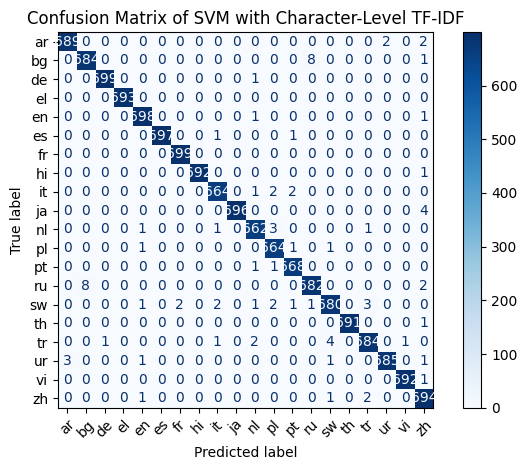

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    labels=svm.classes_,
    xticks_rotation=45,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix of SVM with Character-Level TF-IDF")
plt.tight_layout()
plt.show()

In [32]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes with BoW",
        "Naive Bayes with Character TF-IDF",
        "Logistic Regression with Character TF-IDF",
        "SVM with BoW",
        "SVM with Character TF-IDF",
        "SVM with Word-Level TF-IDF",
        "SVM with Character TF-IDF and Stop Words Removal",
        "SVM with Character TF-IDF and Stemming",
        "SVM with Character TF-IDF and Lemmatization"
    ],
    "Accuracy": [
        nb_accuracy,
        nb_tfidf_accuracy,
        lr_accuracy,
        svm_bow_accuracy,
        svm_accuracy,
        svm_word_accuracy,
        svm_stopwords_accuracy,
        svm_stem_accuracy,
        svm_lemma_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
4,SVM with Character TF-IDF,0.993984
8,SVM with Character TF-IDF and Lemmatization,0.993766
6,SVM with Character TF-IDF and Stop Words Removal,0.993766
7,SVM with Character TF-IDF and Stemming,0.993476
2,Logistic Regression with Character TF-IDF,0.992027
1,Naive Bayes with Character TF-IDF,0.965860
5,SVM with Word-Level TF-IDF,0.924181
3,SVM with BoW,0.919759
0,Naive Bayes with BoW,0.917947


## 8. Optional ALLAM Experiment

This section compares the traditional machine-learning approach with the
`ALLaM-AI/ALLaM-7B-Instruct-preview` model.

Requirements:

1. Run the notebook in Google Colab with a compatible GPU.
2. Add a Hugging Face token to **Colab Secrets** using the name `HF_TOKEN`.
3. Never write the token directly inside the notebook.


In [ ]:
%pip install -q transformers==4.44.2 accelerate==0.34.2 huggingface_hub gradio


In [ ]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN was not found in Colab Secrets.")

login(token=hf_token)


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

ALLAM_MODEL_NAME = "ALLaM-AI/ALLaM-7B-Instruct-preview"
allam_model = None
allam_tokenizer = None

def load_allam():
    global allam_model, allam_tokenizer

    if allam_model is None:
        allam_tokenizer = AutoTokenizer.from_pretrained(ALLAM_MODEL_NAME)
        allam_model = AutoModelForCausalLM.from_pretrained(
            ALLAM_MODEL_NAME,
            torch_dtype=torch.float16,
            device_map="auto"
        )

    return allam_model, allam_tokenizer


In [ ]:
def build_prompt(text):
    return (
        "You are ALLaM, a multilingual AI assistant.\n"
        "Detect the language of the following text.\n"
        "Return only the language name without explanation.\n\n"
        f"Text: {text}"
    )

def predict_with_allam(text):
    model, tokenizer = load_allam()
    query = build_prompt(text)

    messages = [{"role": "user", "content": query}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        return_token_type_ids=False
    ).to(model.device)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=12,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    prediction = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    ).strip()

    return prediction.splitlines()[0] if prediction else ""


In [ ]:
example_text = "معالجة اللغات الطبيعية"
predict_with_allam(example_text)


## 9. Optional Gradio Demo

The interface below runs the ALLAM prediction function. The public link generated by
Gradio is temporary and should not be included as a permanent project URL.


In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_with_allam,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a word or sentence..."
    ),
    outputs=gr.Textbox(label="Detected Language"),
    title="Multilingual Language Identification",
    description="Enter text and the model will predict its language."
)

interface.launch()


## Conclusion

Character-level TF-IDF with Linear SVM produced the best result among the traditional
machine-learning experiments. Character n-grams are effective for language identification
because they capture writing-system and spelling patterns without relying entirely on complete
words.
